In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import plotnine as p9
import itertools
import numpy as np
import sklearn.linear_model
import decimal

In [2]:
BYTES_FLOAT = 4
BYTES_INDEX = 4

# Best Performing Configuration for Each Approach

In [3]:
sliding_windows_df = pd.read_csv('./statistics/best_configurations/sliding_windows.csv')
attention_distillation_df = pd.read_csv('./statistics/best_configurations/attention_distillation.csv')
chefer_importance_df = pd.read_csv('./statistics/best_configurations/chefer_importance.csv')

In [4]:
sliding_windows_df['method'] = 'Sliding Windows'
# sliding_windows_df['param'] = 'w=' + sliding_windows_df['window_size'].astype(str)
#
attention_distillation_df['method'] = 'Attention Distillation'
# attention_distillation_df['param'] = 't=' + attention_distillation_df['threshold'].astype(str)
#
chefer_importance_df['method'] = 'Chefer Importance'
# chefer_importance_df['param'] = ('nt=' + chefer_importance_df['node_threshold'].astype(str) + '_et=' + chefer_importance_df['edge_threshold'].astype(str))


In [5]:
common_columns = ['dataset', 'split', 'index','document_length', 'token_count','node_count', 'node_embedding_dimension','edge_count', 'edge_embedding_dimension', 'method']#, 'param']
df = pd.concat([sliding_windows_df[common_columns], attention_distillation_df[common_columns], chefer_importance_df[common_columns]], ignore_index = True)

In [6]:
df['node_memory'] = df['node_count'] * df['node_embedding_dimension'] * BYTES_FLOAT
df['edge_feature_memory'] = df['edge_count'] * df['edge_embedding_dimension'] * BYTES_FLOAT
df['edge_index_memory'] = df['edge_count'] * 2 * BYTES_INDEX
df['total_bytes'] = df['node_memory'] + df['edge_feature_memory'] + df['edge_index_memory']
df['total_mega_bytes'] = df['total_bytes'] / (1024**2)
#
df['memory_per_token'] = df['total_bytes'] / df['token_count']
#
df['edge_node_ratio'] = df['edge_count'] / df['node_count']
#
df['graph_density'] = df['edge_count'] / (df['node_count'] ** 2)

## Memory per Document over Document Length

In [15]:
# p9.geom_smooth(p9.aes(colour = 'method'), method = 'lm') + \
# p9.scale_color_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \ (guide = False on fill)
plot = p9.ggplot(
    df,
    p9.aes(x = 'document_length', y = 'total_mega_bytes', fill = 'method')
  ) + \
    p9.geom_point(size = 3.5, stroke = 0.25) + \
    p9.xlab('Document Length') + \
    p9.ylab('Memory per Document (MB)') + \
    p9.labs(fill = 'Approach') + \
    p9.facet_wrap(facets = '~ dataset', ncol = 2, scales = 'free') + \
    p9.theme_bw() + \
    p9.scale_fill_manual(values = ['#ef8a62', '#67a9cf', '#ffd760', '#f7f7f7']) + \
    p9.guides(
      fill = p9.guide_legend(override_aes = {'size': 8})
    ) + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
      subplots_adjust = {
        'wspace' : 0.075,
        'hspace' : 0.15
      }
    )

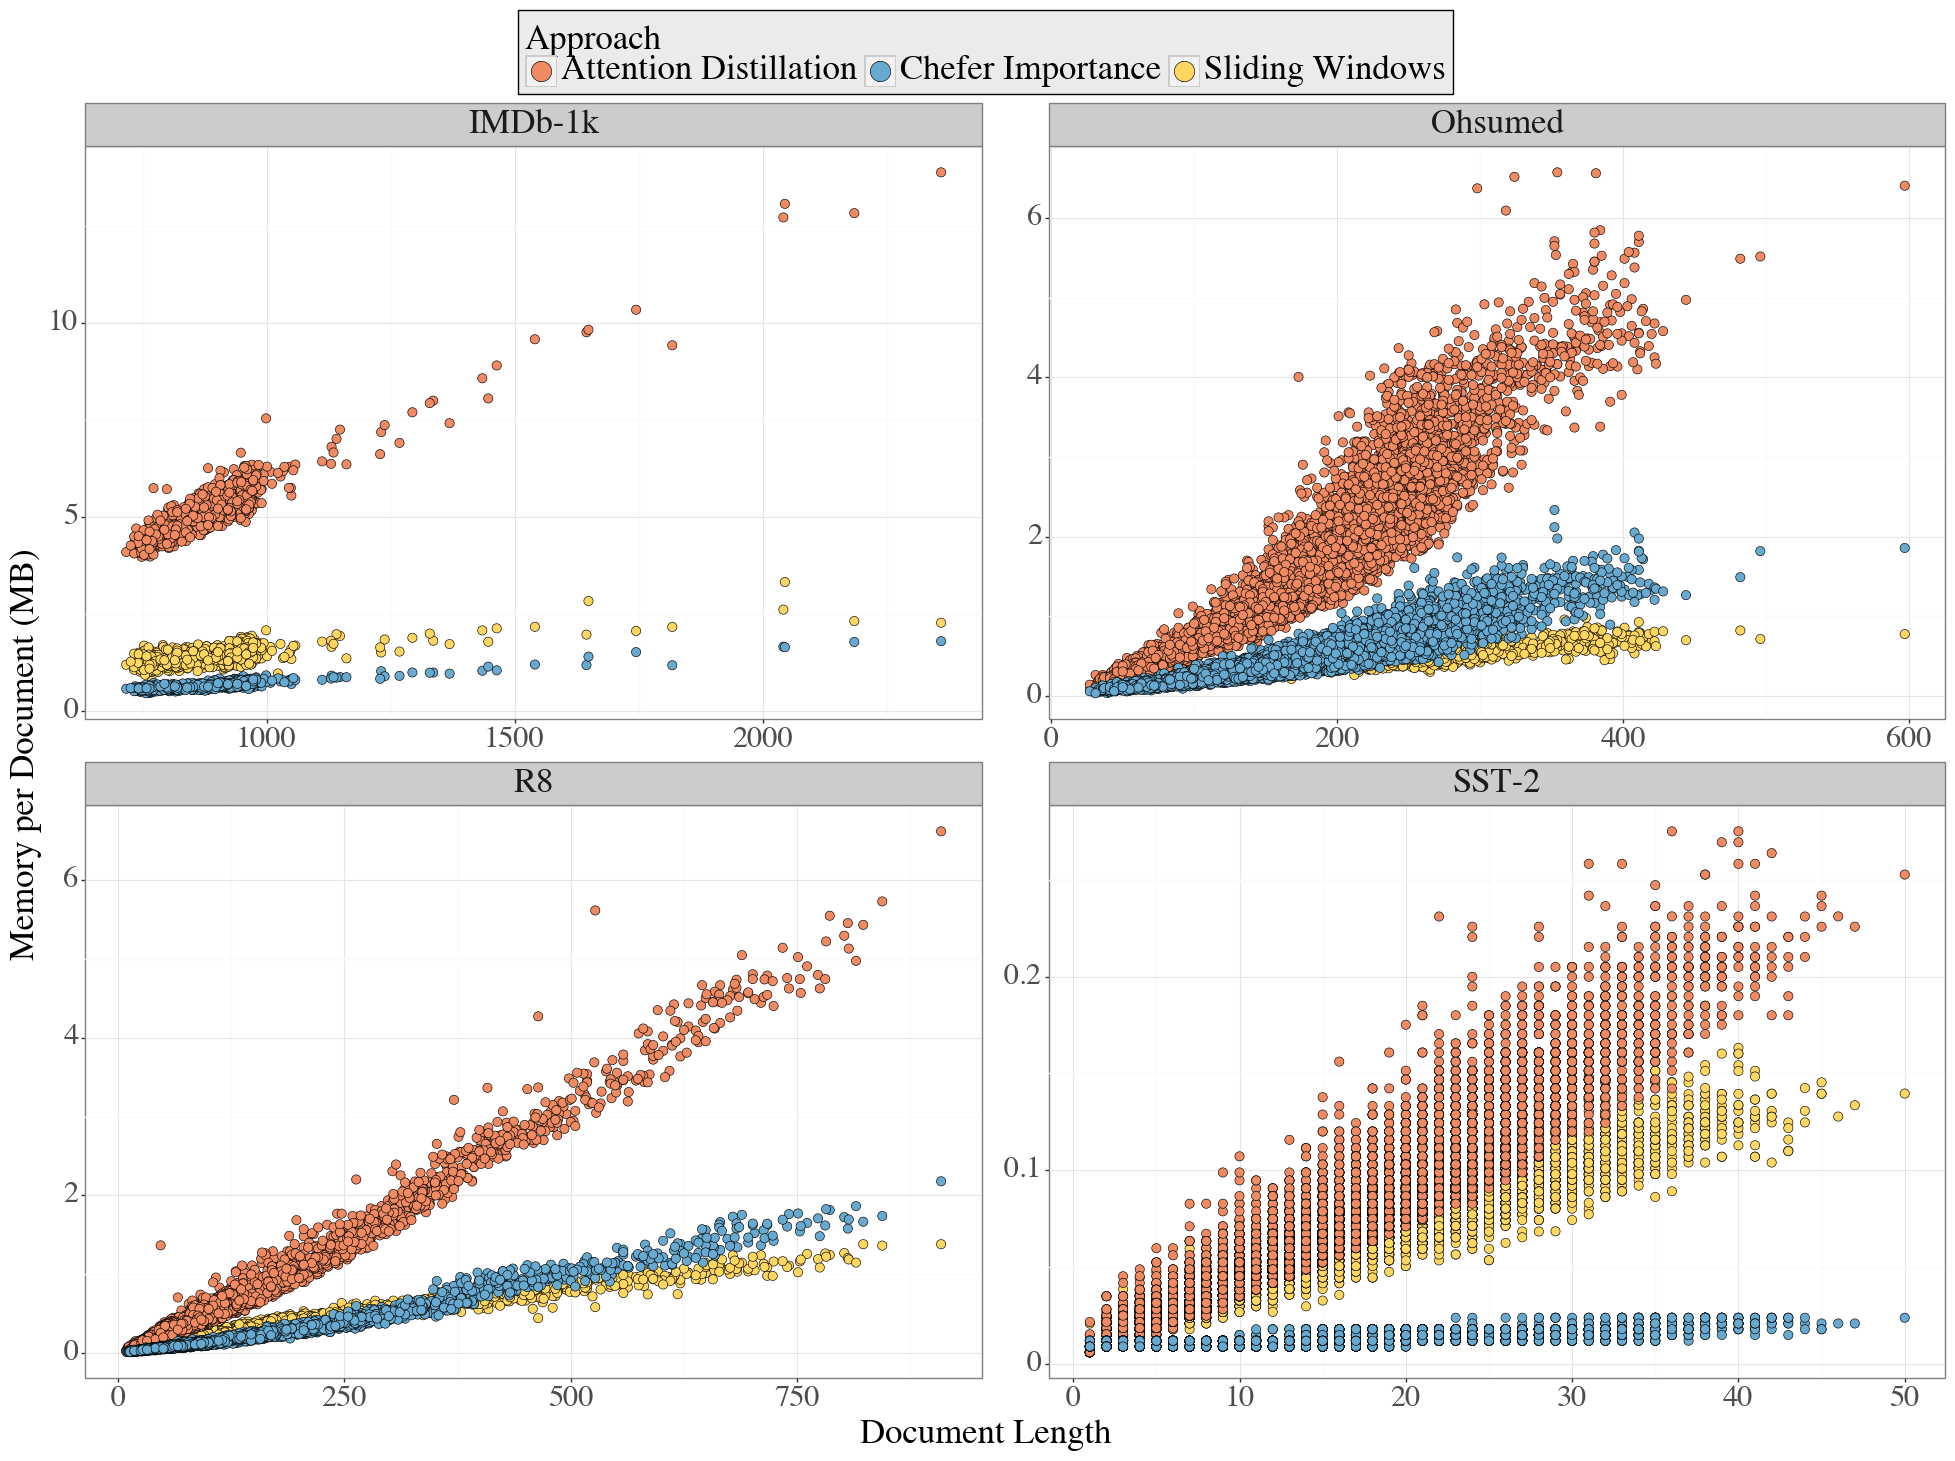

<ggplot: (336649012)>

In [16]:
plot

In [17]:
plot.save(filename = '../figures/memory_per_document_best_configurations.png', dpi = 300)

## Node and Edge Counts, Edge-to-Node Ratio, and Graph Density

In [10]:
statistics_df = df.groupby(by = ['dataset', 'method']).agg({'node_count' : ['mean', 'std'], 'edge_count' : ['mean', 'std'], 'edge_node_ratio' : ['mean', 'std'], 'graph_density' : ['mean', 'std']}).reset_index()
statistics_df.loc[:, ('graph_density', ['mean', 'std'])] *= 100
statistics_df
statistics_df[statistics_df.select_dtypes(include = 'number').columns] = (
  statistics_df.select_dtypes(include = 'number').applymap(lambda x : float(decimal.Decimal(str(x)).quantize(decimal.Decimal('0.01'), rounding = decimal.ROUND_HALF_UP)))
)
statistics_df

dataset                  method node_count         edge_count            \
                                          mean     std       mean       std   
0   IMDb-1k  Attention Distillation    1163.43  186.80   32615.59   6159.69   
1   IMDb-1k       Chefer Importance     205.78   36.18    4159.77    784.24   
2   IMDb-1k         Sliding Windows     478.30   69.35    1462.69    207.46   
3   Ohsumed  Attention Distillation     285.11  122.66   16922.49  12985.31   
4   Ohsumed       Chefer Importance      93.78   42.51    2454.79   1867.02   
5   Ohsumed         Sliding Windows     135.37   42.83     568.37    205.09   
6        R8  Attention Distillation     151.19  150.36    2736.01   5576.67   
7        R8       Chefer Importance      44.11   48.01    1195.89   2457.06   
8        R8         Sliding Windows      79.30   62.26     450.02    421.77   
9     SST-2  Attention Distillation      22.96   11.00     259.67    234.15   
10    SST-2       Chefer Importance       4.39    1.10       8.69      3.17   
11    SST-2         Sliding Windows      20.71    9.26      63.48     30.47   

   edge_node_ratio        graph_density         
              mean    std          mean    std  
0            27.94   0.77          2.44   0.25  
1            20.20   0.91         10.03   1.37  
2             3.06   0.14          0.65   0.11  
3            50.66  20.52         17.90   0.61  
4            22.71   8.56         25.03   3.46  
5             4.13   0.32          3.39   1.19  
6            10.04   8.40          6.95   0.40  
7            15.61  11.79         39.55   5.83  
8             5.29   0.67         10.05   6.21  
9             9.21   4.39         40.22   0.81  
10            1.93   0.24         45.36   6.76  
11            3.01   0.19         18.63  11.47

In [11]:
# print(statistics_df.to_latex(index = False, float_format = '%.2f'))

# Various Configurations from Our Method

In [12]:
df_list = list()
for file in os.listdir('./statistics/various_configurations/chefer_importance'):
  if file.endswith('.csv'):
    df_list.append(pd.read_csv(os.path.join('./statistics/various_configurations/chefer_importance', file)))
df = pd.concat(df_list, ignore_index = True)
df['param'] = ('nt=' + df['node_threshold'].astype(str) + '_et=' + df['edge_threshold'].astype(str))

In [13]:
df['node_memory'] = df['node_count'] * df['node_embedding_dimension'] * BYTES_FLOAT
df['edge_feature_memory'] = df['edge_count'] * df['edge_embedding_dimension'] * BYTES_FLOAT
df['edge_index_memory'] = df['edge_count'] * 2 * BYTES_INDEX
df['total_bytes'] = df['node_memory'] + df['edge_feature_memory'] + df['edge_index_memory']
df['total_mega_bytes'] = df['total_bytes'] / (1024**2)
#
df['memory_per_token'] = df['total_bytes'] / df['token_count']
#
df['edge_node_ratio'] = df['edge_count'] / df['node_count']
#
df['graph_density'] = df['edge_count'] / (df['node_count'] ** 2)

In [14]:
chefer_importance_memory_df = df[df['param'].isin([f'nt={x}_et={y}' for (x, y) in itertools.product([0.5, 0.6, 0.7, 0.8, 0.9, 0.95], repeat = 2)])]
chefer_importance_memory_df[['nt', 'et']] = chefer_importance_memory_df['param'].str.extract(r'nt=(.*)_et=(.*)').astype(float)
chefer_importance_summary_df = chefer_importance_memory_df.groupby(['dataset', 'nt', 'document_length']) \
  .agg(
    mean_mega_bytes = ('total_mega_bytes', 'mean'),
    min_mega_bytes = ('total_mega_bytes', 'min'),
    max_mega_bytes = ('total_mega_bytes', 'max')
  ) \
  .reset_index()
chefer_importance_summary_df['nt'] = 'Token Threshold = ' + chefer_importance_summary_df['nt'].astype(str)

### IMDb-1k

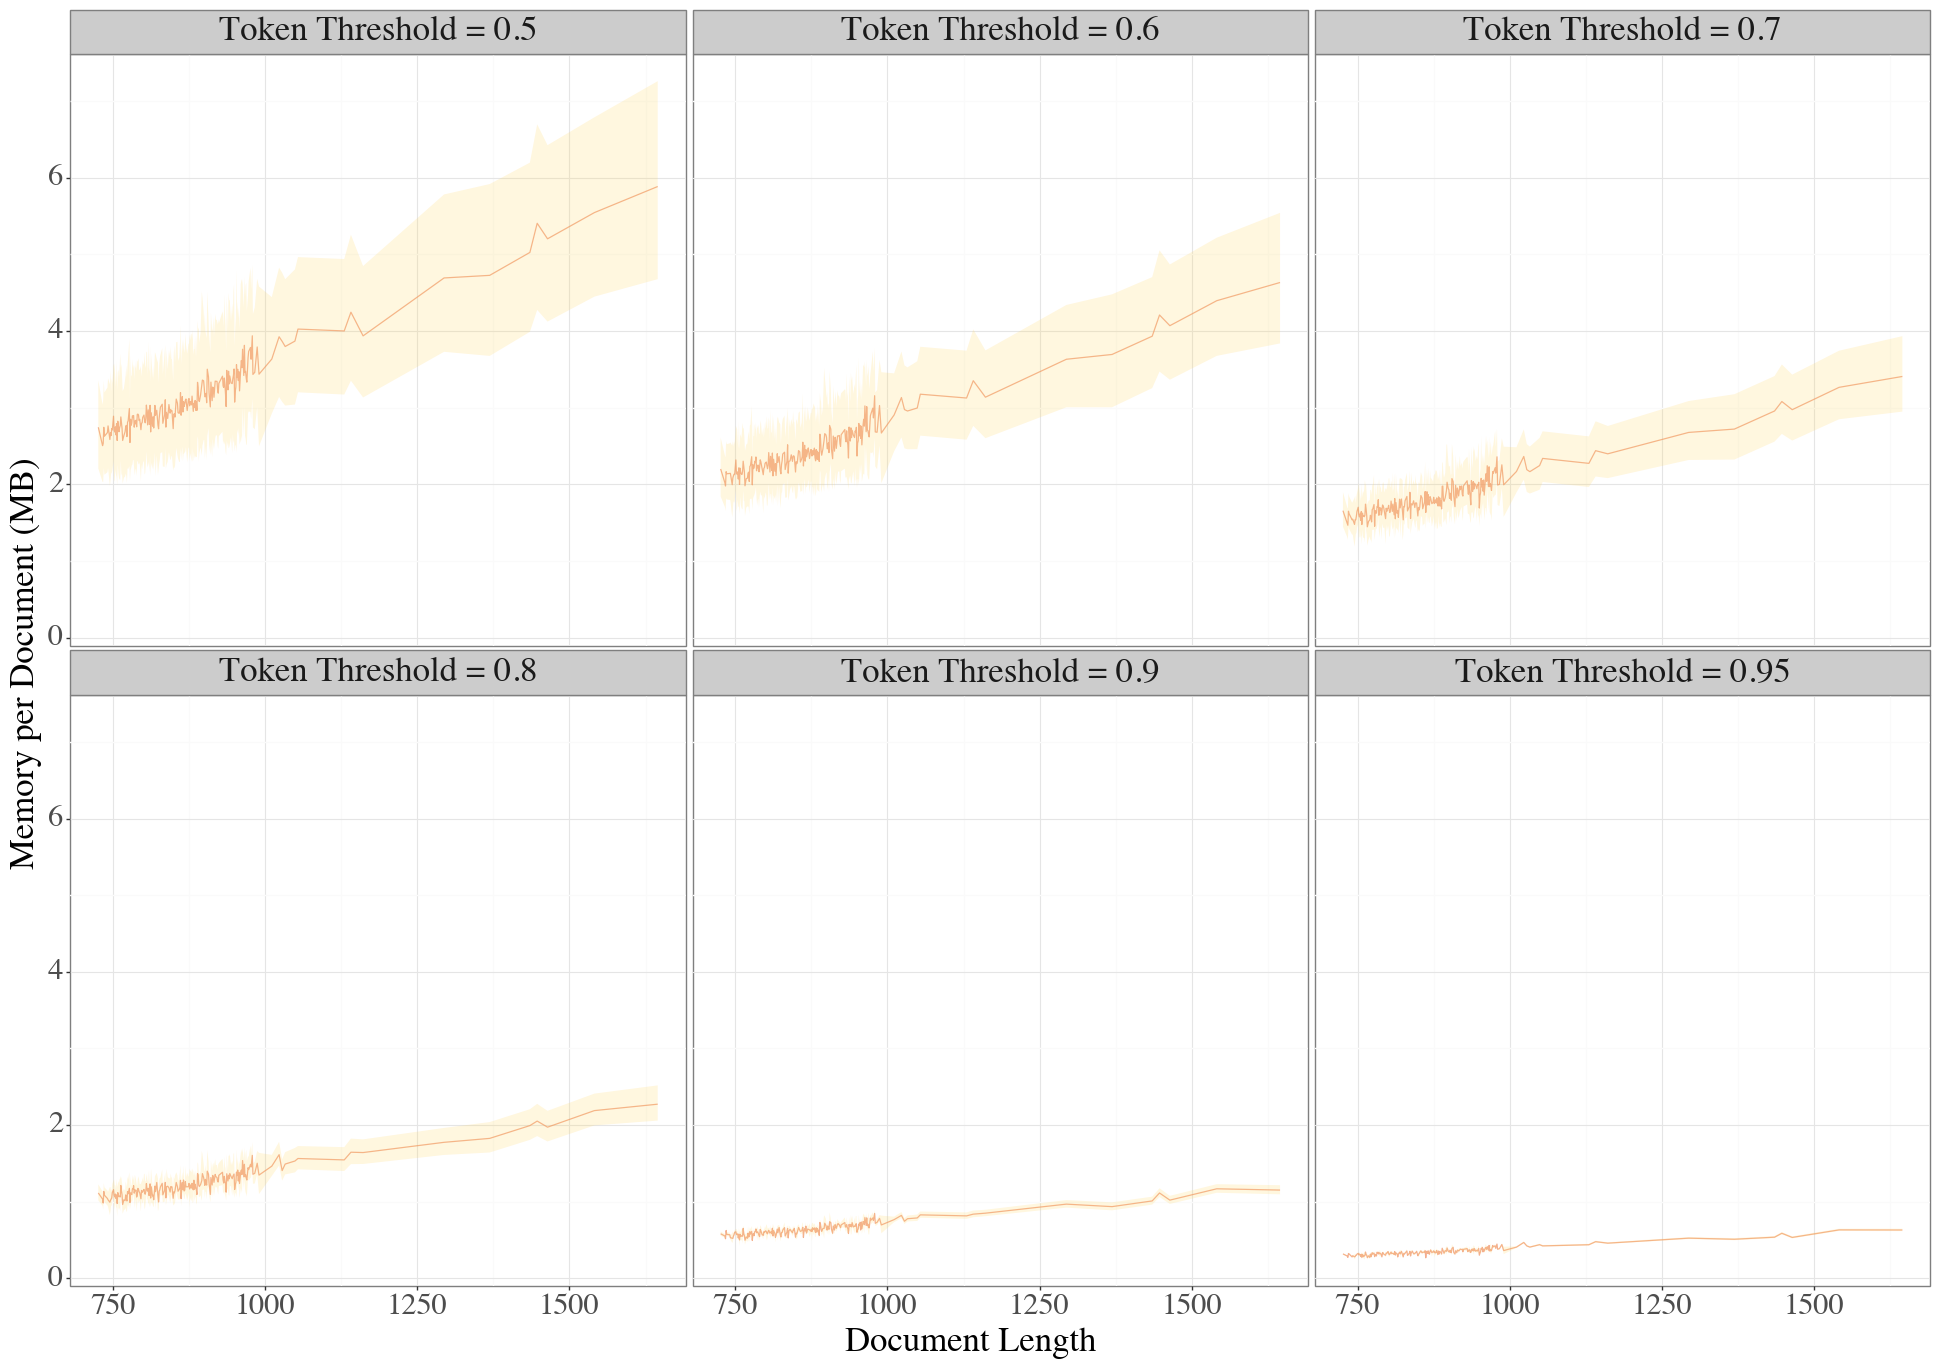

<ggplot: (331843894)>

In [15]:
p9.ggplot(
    chefer_importance_summary_df[chefer_importance_summary_df['dataset'] == 'IMDb-1k'],
    p9.aes(x = 'document_length')
  ) + \
    p9.geom_line(p9.aes(y = 'mean_mega_bytes'), alpha = 0.7, color = '#ef8a62') + \
    p9.geom_ribbon(p9.aes(ymin = 'min_mega_bytes', ymax = 'max_mega_bytes'), alpha = 0.2, fill = '#ffd760') + \
    p9.xlab('Document Length') + \
    p9.ylab('Memory per Document (MB)') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ nt', ncol = 3) + \
    p9.theme_bw() + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

### Ohsumed

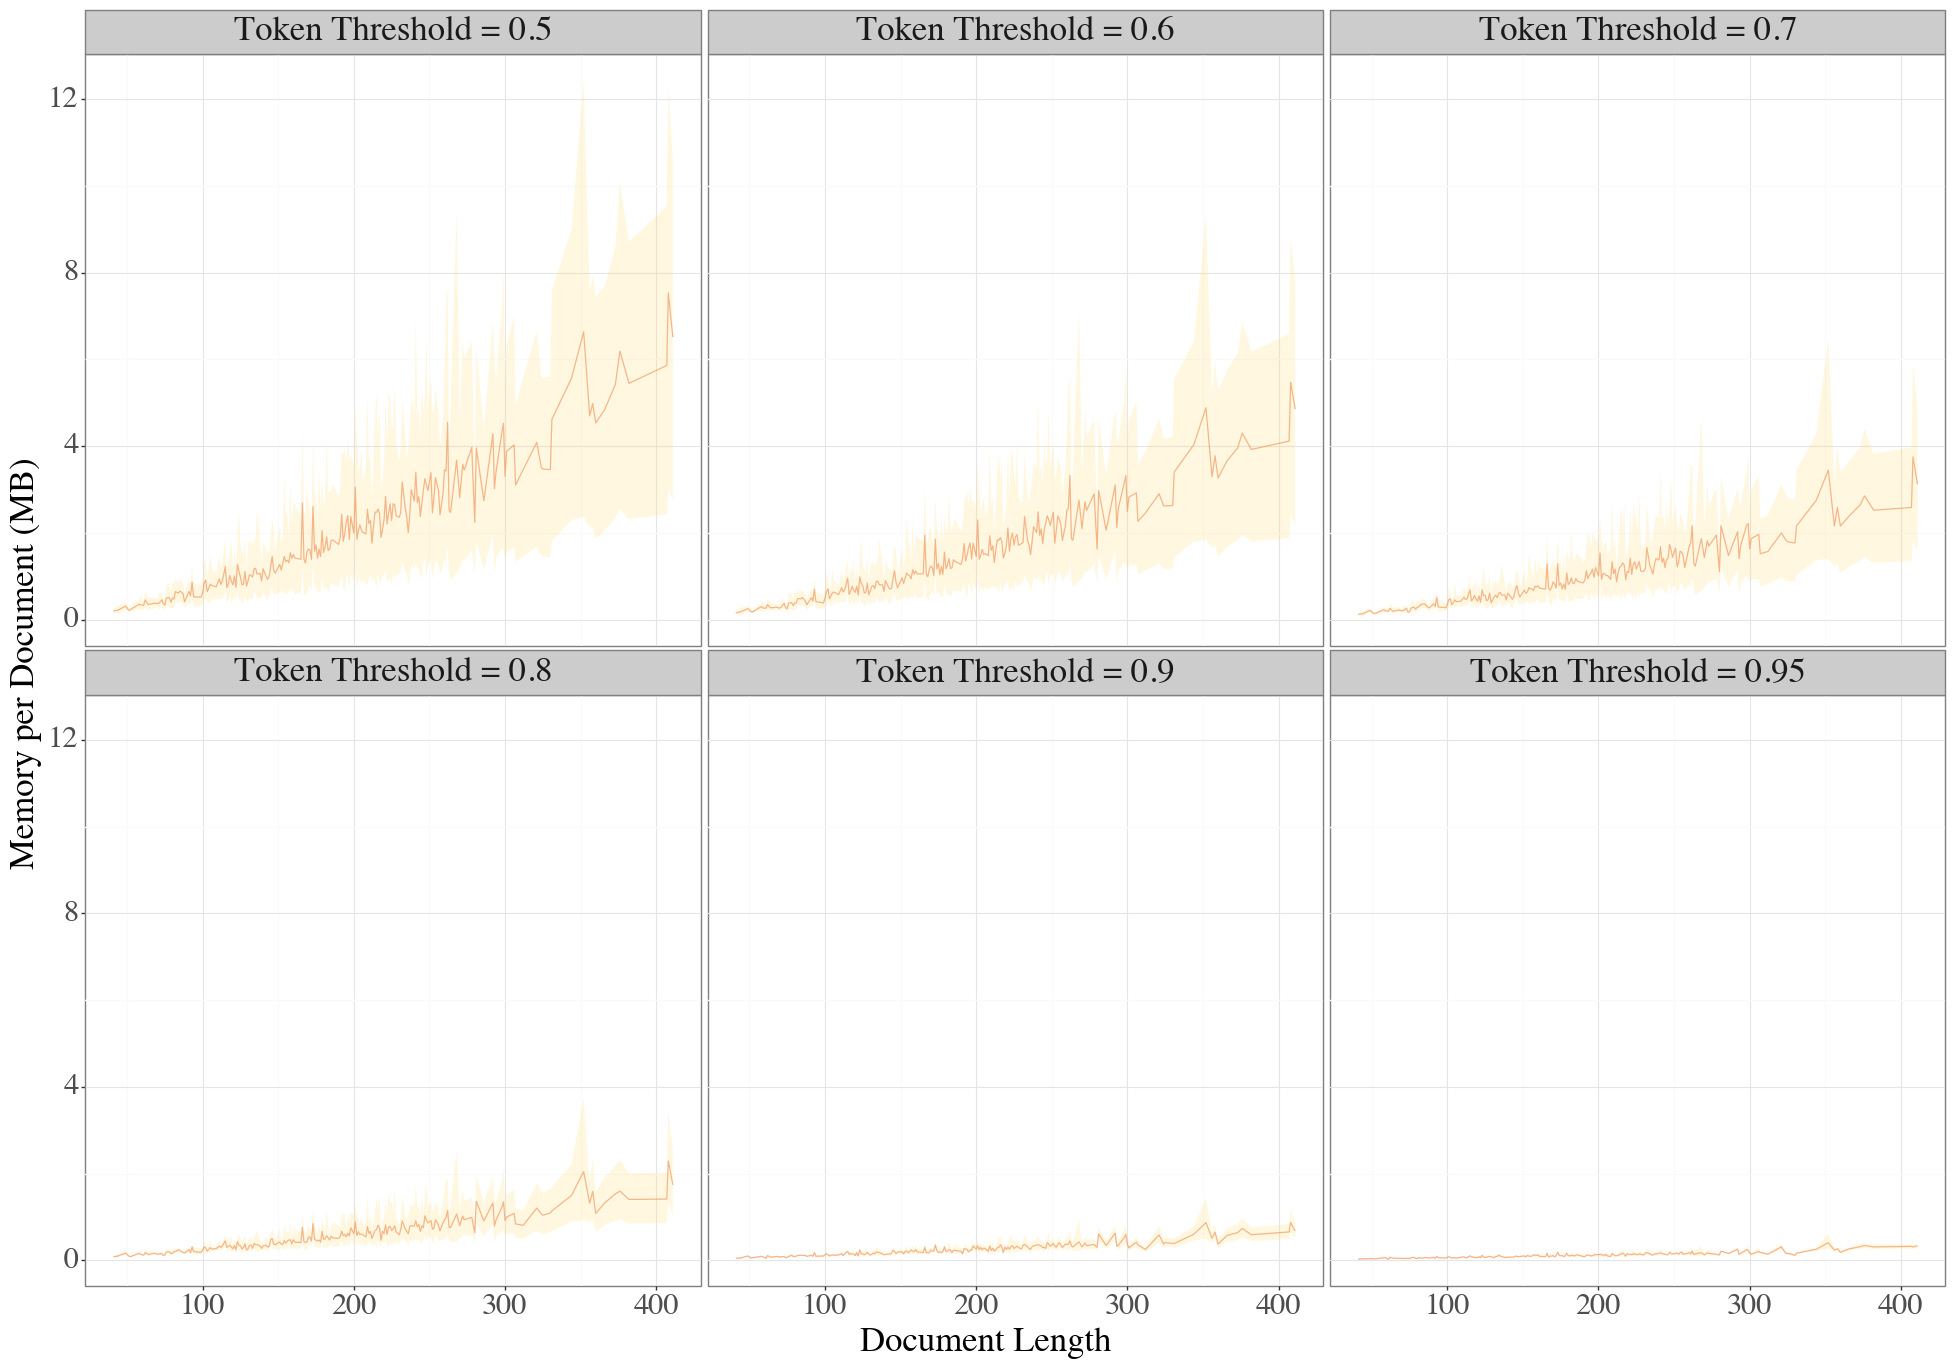

<ggplot: (334559356)>

In [16]:
p9.ggplot(
    chefer_importance_summary_df[chefer_importance_summary_df['dataset'] == 'Ohsumed'],
    p9.aes(x = 'document_length')
  ) + \
    p9.geom_line(p9.aes(y = 'mean_mega_bytes'), alpha = 0.7, color = '#ef8a62') + \
    p9.geom_ribbon(p9.aes(ymin = 'min_mega_bytes', ymax = 'max_mega_bytes'), alpha = 0.2, fill = '#ffd760') + \
    p9.xlab('Document Length') + \
    p9.ylab('Memory per Document (MB)') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ nt', ncol = 3) + \
    p9.theme_bw() + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

### R8

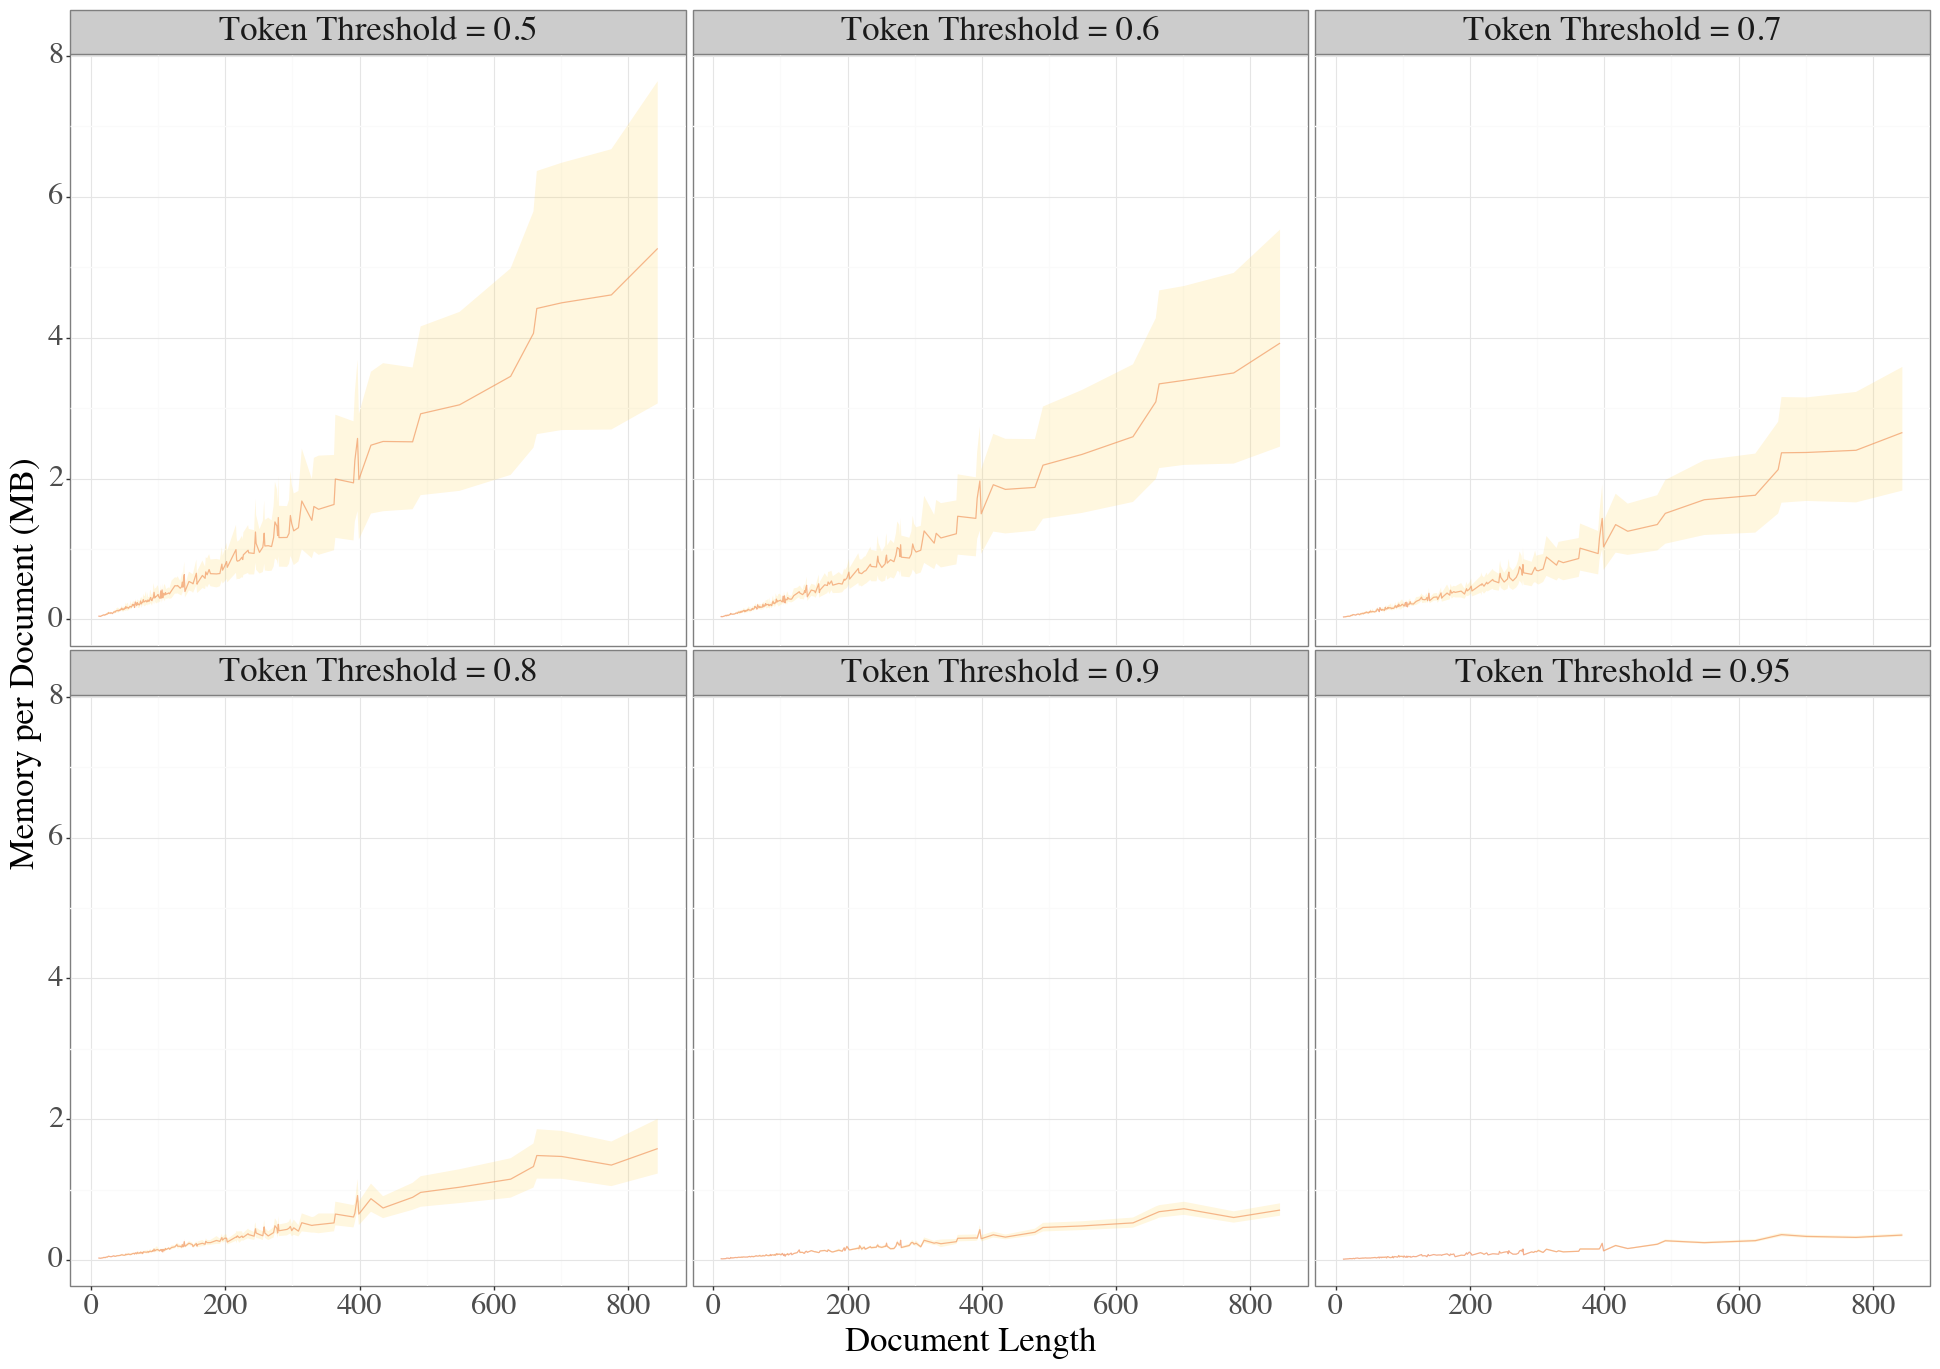

<ggplot: (331884854)>

In [17]:
p9.ggplot(
    chefer_importance_summary_df[chefer_importance_summary_df['dataset'] == 'R8'],
    p9.aes(x = 'document_length')
  ) + \
    p9.geom_line(p9.aes(y = 'mean_mega_bytes'), alpha = 0.7, color = '#ef8a62') + \
    p9.geom_ribbon(p9.aes(ymin = 'min_mega_bytes', ymax = 'max_mega_bytes'), alpha = 0.2, fill = '#ffd760') + \
    p9.xlab('Document Length') + \
    p9.ylab('Memory per Document (MB)') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ nt', ncol = 3) + \
    p9.theme_bw() + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

### SST-2

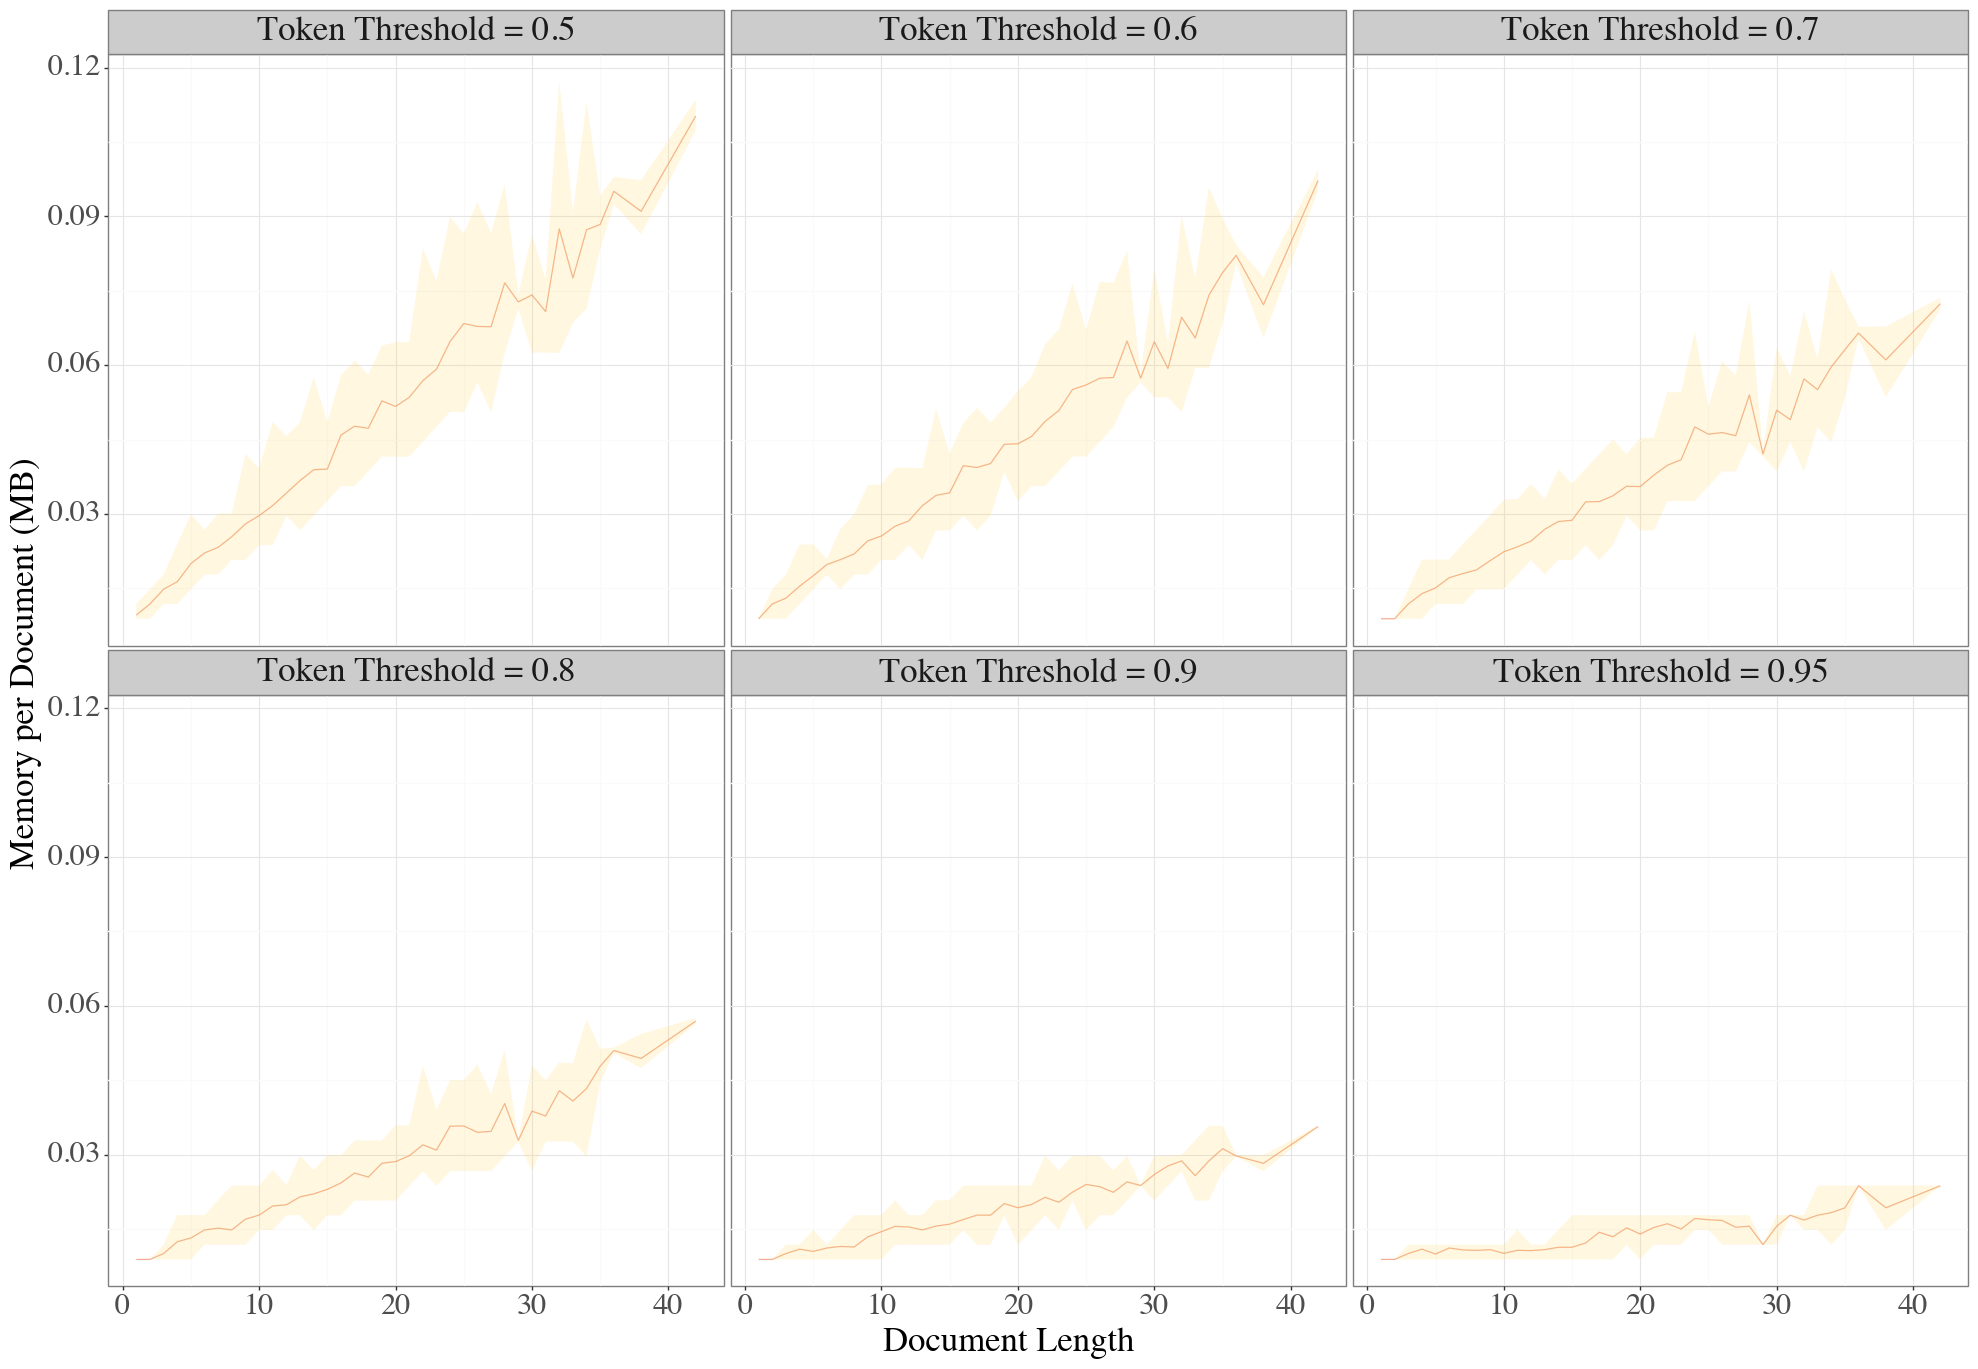

<ggplot: (332408127)>

In [18]:
p9.ggplot(
    chefer_importance_summary_df[chefer_importance_summary_df['dataset'] == 'SST-2'],
    p9.aes(x = 'document_length')
  ) + \
    p9.geom_line(p9.aes(y = 'mean_mega_bytes'), alpha = 0.7, color = '#ef8a62') + \
    p9.geom_ribbon(p9.aes(ymin = 'min_mega_bytes', ymax = 'max_mega_bytes'), alpha = 0.2, fill = '#ffd760') + \
    p9.xlab('Document Length') + \
    p9.ylab('Memory per Document (MB)') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ nt', ncol = 3) + \
    p9.theme_bw() + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )

_____________

# Edge Count vs Document Length

In [19]:
chefer_importance_memory_df = df[df['param'].isin([f'nt={x}_et={y}' for (x, y) in itertools.product([0.5, 0.6, 0.7, 0.8, 0.9, 0.95], repeat = 2)])]
chefer_importance_memory_df[['nt', 'et']] = chefer_importance_memory_df['param'].str.extract(r'nt=(.*)_et=(.*)').astype(float)
chefer_importance_summary_df = chefer_importance_memory_df.groupby(['nt', 'document_length']) \
  .agg(
    mean_edge_count = ('edge_count', 'mean'),
    min_edge_count = ('edge_count', 'min'),
    max_edge_count = ('edge_count', 'max')
  ) \
  .reset_index()

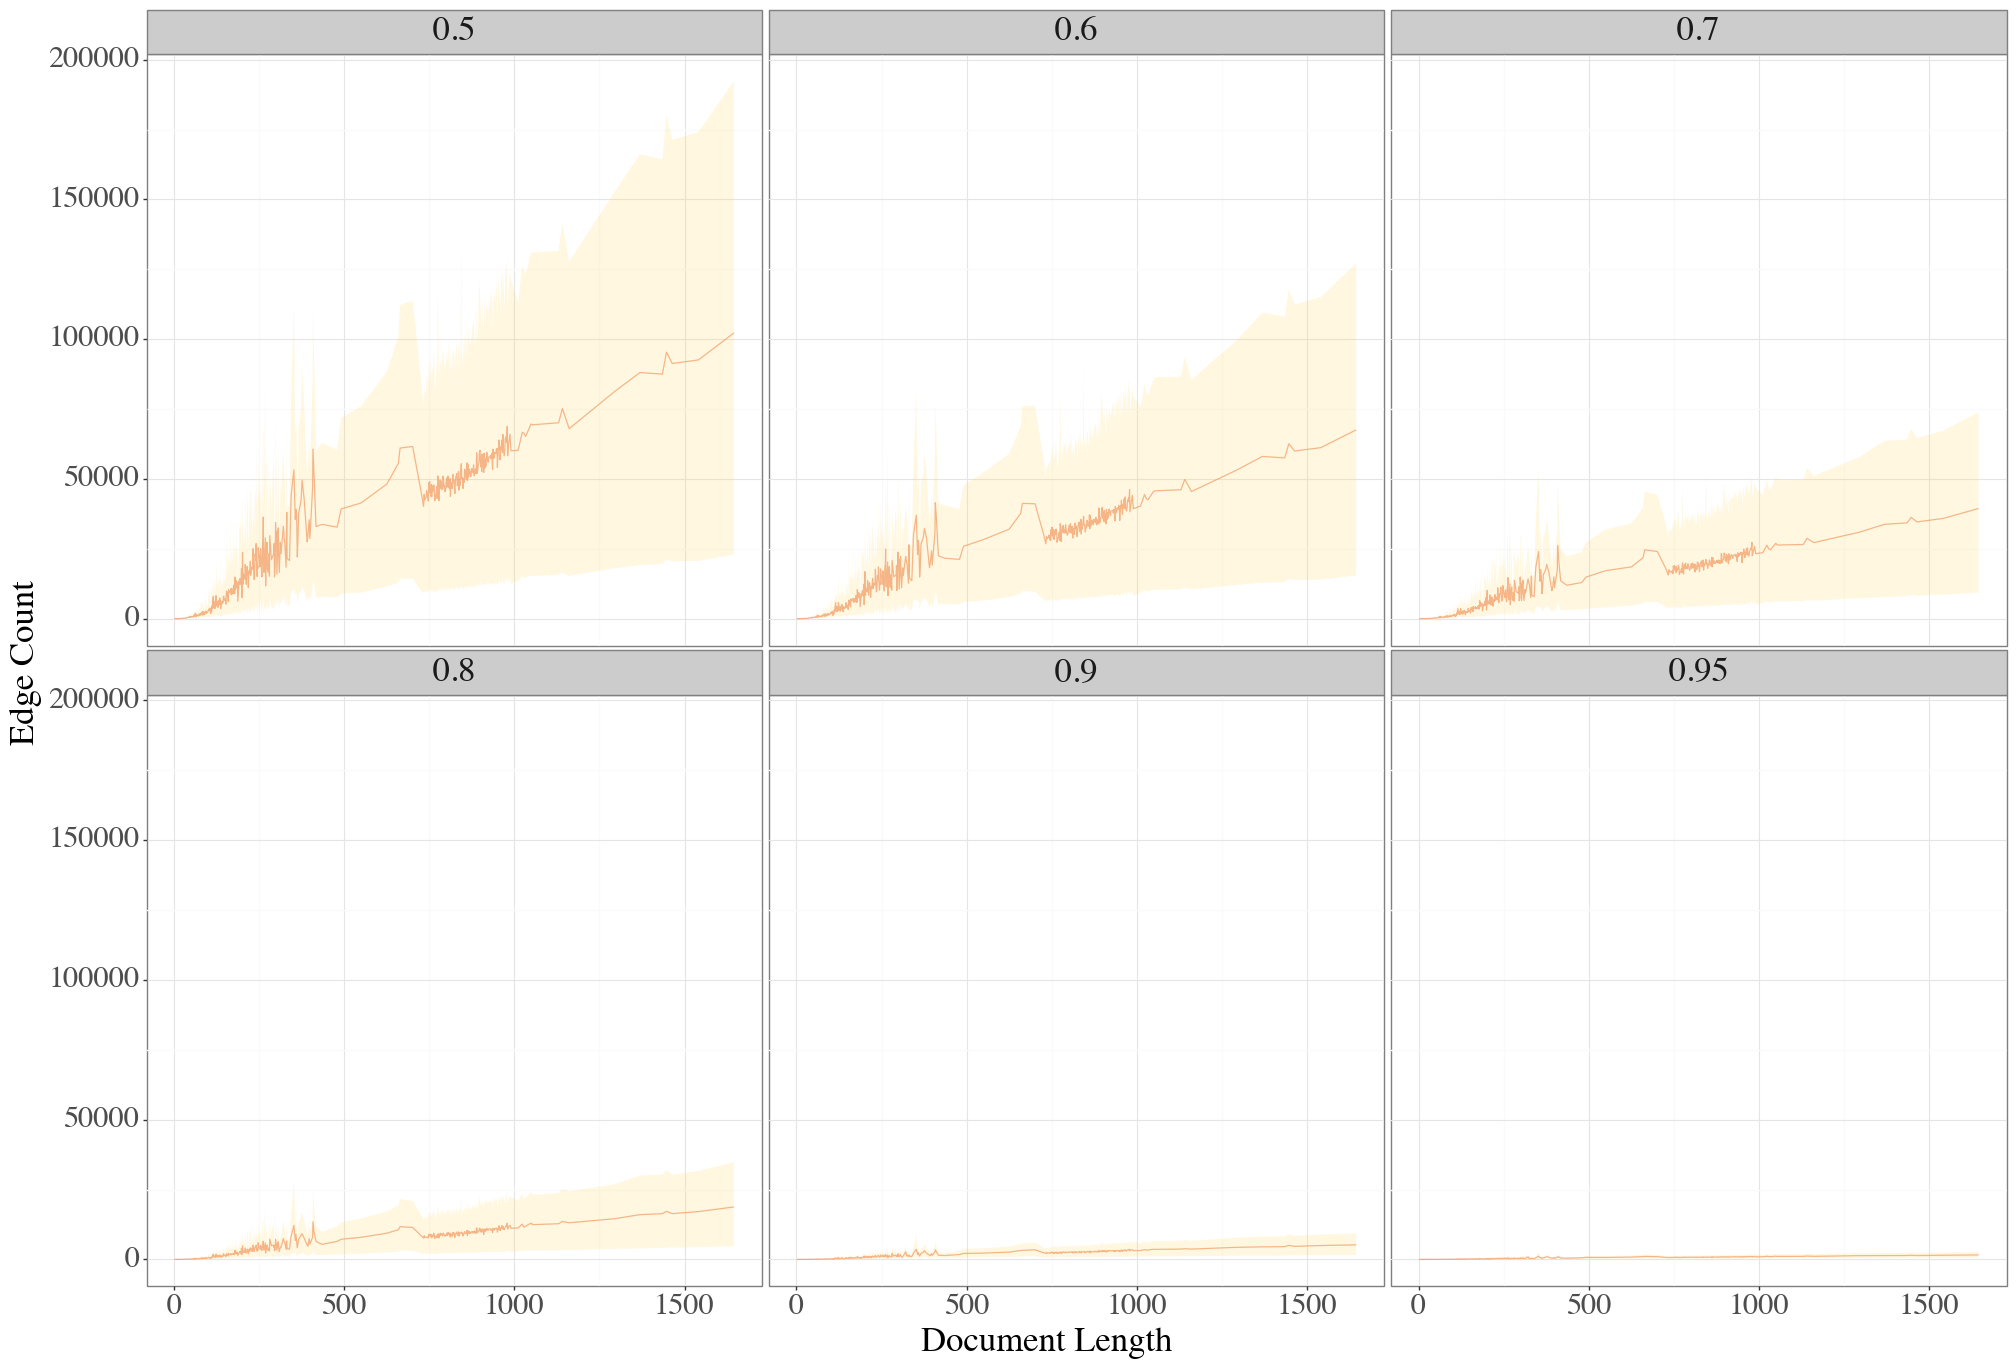

<ggplot: (334522176)>

In [20]:
p9.ggplot(
    chefer_importance_summary_df,
    p9.aes(x = 'document_length')
  ) + \
    p9.geom_line(p9.aes(y = 'mean_edge_count'), alpha = 0.7, color = '#ef8a62') + \
    p9.geom_ribbon(p9.aes(ymin = 'min_edge_count', ymax = 'max_edge_count'), alpha = 0.2, fill = '#ffd760') + \
    p9.xlab('Document Length') + \
    p9.ylab('Edge Count') + \
    p9.labs(color = 'Method') + \
    p9.facet_wrap(facets = '~ nt', ncol = 3) + \
    p9.theme_bw() + \
    p9.theme(
      legend_position = 'top',
      legend_background = p9.element_rect(color = '#000000', fill = '#ebebeb'),
      legend_box_margin = 0,
      figure_size = (24, 16),
      text = p9.element_text(size = 25, family = 'serif'),
      axis_text = p9.element_text(size = 22),
      axis_title = p9.element_text(weight = 'bold'),
      legend_title = p9.element_text(weight = 'bold'),
    )